# Simple case D estimation

Simple study case: 1 particles spawns at (row, col) = (64, 10) (middle of left side) and jumps 10 by 10 pixels in a straight line to the right.  
Its D should be

In [1]:
from Helpers import *
from helpersGeneration import *
from helpersTracking import *
from helpersStatistics import *
from helpersAssignment import *
%reload_ext autoreload
%autoreload 2
import Helpers, helpersGeneration, helpersTracking, helpersStatistics, helpersAssignment

In [2]:
def update_straight(Particles):
    for p in Particles:
        p.center = (p.center[0], p.center[1] + 5) # move down by 5 pixels
    return Particles

In [3]:
particles = []
particles.append(Particle(0, 64, 10, 0)) # D_GT to set correctly
particles.append(Particle(1, 100, 64, 0))

In [4]:
D_GT = [20.833333333333332, 20.833333333333332] # to fix???

In [5]:
frames = []
trajectories_GT = [Trajectory(p.ID, initial_position=p.center) for p in particles] # GT trajectories for each particle
D_GT = [p.d for p in particles] # GT diffusion coefficients for each particle
for f in range(4):
    print(f"Frame {f}")
    img = uniform_bg(128, value=100) # background
    img = add_gaussian_noise(img, mean=0, std=30)
    img = add_poisson_noise(img)
    img_with_particles = place_particles(img, particles, c=1500)
    frames.append(img_with_particles)
    particles = update_straight(particles)
    for i, p in enumerate(particles):
        trajectories_GT[i].add_position(p.center)

print("GT trajectories:")
for traj in trajectories_GT:
    traj.print_trajectory()

Frame 0
Frame 1
Frame 2
Frame 3
GT trajectories:
Trajectory 0:
64.0 10.0
64.0 15.0
64.0 20.0
64.0 25.0
64.0 30.0
Trajectory 1:
100.0 64.0
100.0 69.0
100.0 74.0
100.0 79.0
100.0 84.0


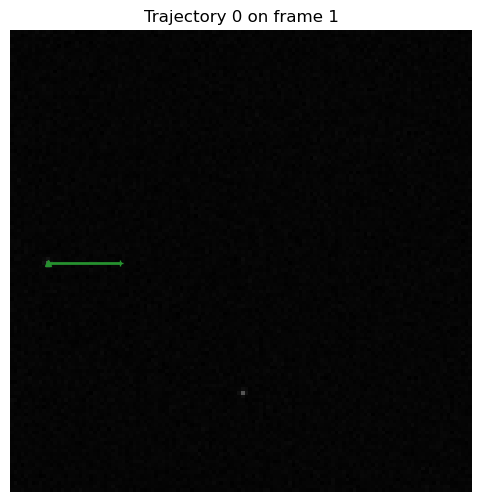

In [6]:
show_trajectory(frames, trajectories_GT, 0, 0)

In [7]:
msd = msd_trajectory(trajectories_GT[0])
print(msd)

[  0.  25. 100. 225. 400.]


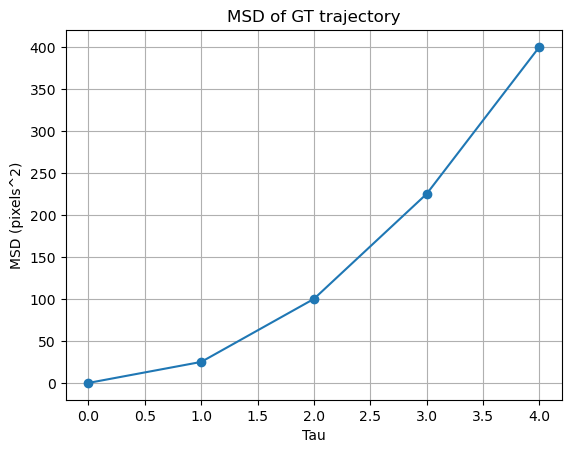

In [8]:
# plot MSD
plt.figure()
plt.plot(msd, marker='o')
plt.title('MSD of GT trajectory')
plt.xlabel('Tau')
plt.ylabel('MSD (pixels^2)')
plt.grid()
plt.show()

In 2D: MSD($ \tau $) = 4D $ \tau $  
  
=> valid only in **isotropic free diffusion regime**  
  
=> MSD grows quadratically with $ \tau $ in the case of a constant linear mvt at speed $ v $ pixels/frame: MSD($ \tau $) = $ v^2 $ $ \tau^2 $ => not a good indicator to calibrate the estimation of D.


In [9]:
D_trajectory = estimateDfromMSD(msd, np.arange(len(msd)))
print(D_trajectory)

20.833333333333332


-> what is D_GT?

Fitted center for peak at (100, 64): (99.99, 64.02), amplitude 1571.36, sigma 0.50


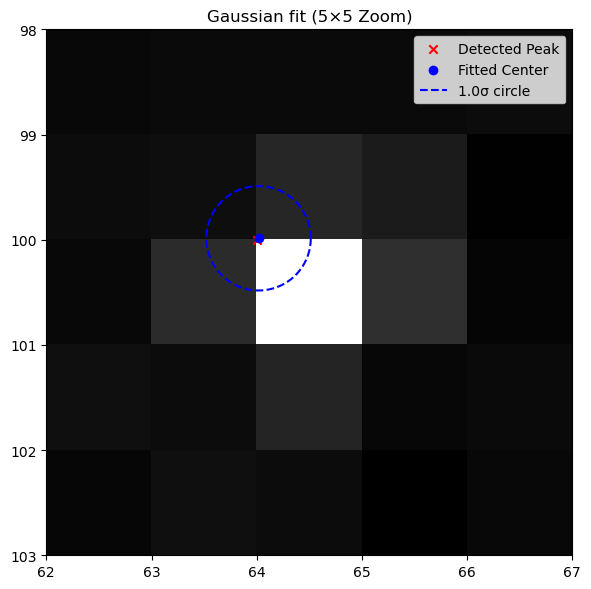

Fitted center for peak at (64, 10): (64.02, 10.02), amplitude 1474.17, sigma 0.52
Fitted center for peak at (100, 69): (100.00, 68.98), amplitude 1518.35, sigma 0.49
Fitted center for peak at (64, 15): (64.03, 14.97), amplitude 1504.10, sigma 0.49
Fitted center for peak at (100, 74): (100.01, 74.03), amplitude 1534.35, sigma 0.48
Fitted center for peak at (64, 20): (63.98, 20.05), amplitude 1524.23, sigma 0.49
Fitted center for peak at (100, 79): (100.00, 78.99), amplitude 1507.24, sigma 0.49
Fitted center for peak at (64, 25): (64.02, 24.95), amplitude 1487.50, sigma 0.51


In [10]:
trajectories_detection, trajectories_localization = compute_d_l_trajectories(frames, trajectories_GT, D_GT)

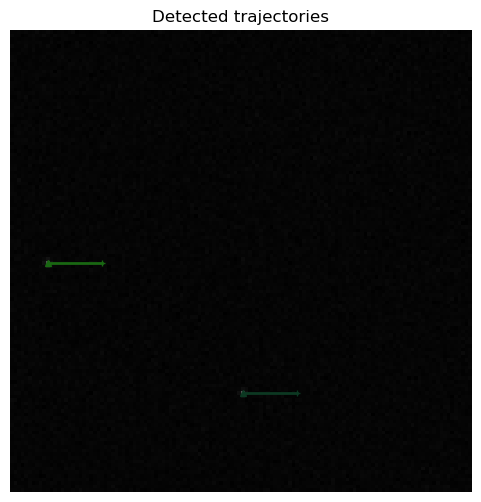

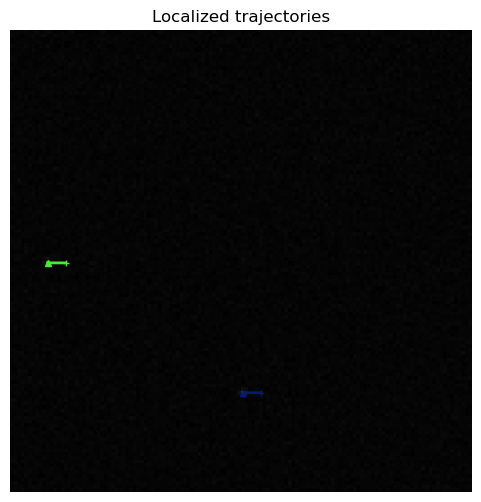

In [11]:
show_trajectories(frames, trajectories_detection, title="Detected trajectories")
show_trajectories(frames, trajectories_localization, title="Localized trajectories")

In [12]:
trajectories_detection, min_cost_detection, assignment_detection = assign_trajectories(trajectories_detection, trajectories_GT, algorithm='hungarian')

In [13]:
trajectories_localization, min_cost_localization, assignment_localization = assign_trajectories(trajectories_localization, trajectories_GT, algorithm='hungarian')

In [14]:
D_detection = compute_D_detection(trajectories_detection, D_GT)

D_detection:
['16.071', '16.071']


In [15]:
D_localization = compute_D_localization(trajectories_localization, D_GT)

D_localization:
['6.125', '6.168']
